# LIBRERIAS

In [40]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import dask
import netCDF4
import xarray as xr
import rioxarray
import seaborn as sns
import math

# LECTURA DE DATOS

In [6]:
data_dir = Path("./Estaciones Aut - Precipitación")

data_files = list(data_dir.glob("*.data"))

print(f"Archivos encontrados: {len(data_files)}")

Archivos encontrados: 611


In [7]:
def read_climate_data(file_path, chunksize=300_000):
    chunks = []

    for chunk in pd.read_csv(
        file_path,
        sep="|",
        parse_dates=["Fecha"],
        dtype={"Valor": "float32"},
        chunksize=chunksize
    ):
        # Metadatos desde el nombre del archivo
        chunk["station_id"] = file_path.stem.split("@")[-1]
        chunk["variable"] = file_path.stem.split("@")[0]

        chunks.append(chunk)

    return pd.concat(chunks, ignore_index=True)

In [8]:
dfs = []

for file in data_files:
    df = read_climate_data(file)
    dfs.append(df)

climate_df = pd.concat(dfs, ignore_index=True)

In [9]:
print(climate_df.head())

                Fecha  Valor station_id   variable
0 2019-07-06 00:20:00    0.0   11017020  PT_AUT_10
1 2019-07-06 00:30:00    0.0   11017020  PT_AUT_10
2 2019-07-06 00:40:00    0.0   11017020  PT_AUT_10
3 2019-07-06 00:50:00    0.0   11017020  PT_AUT_10
4 2019-07-06 01:00:00    0.0   11017020  PT_AUT_10


# PUNTO 1

In [10]:
# df ya leído desde parquet
df = climate_df.sort_values("Fecha").set_index("Fecha")

# Opcional: filtrar mínimo 10 años
df = df.loc["2010-01-01":]

In [11]:
print(df.index.min(), df.index.max())

2010-01-01 00:00:00 2023-04-07 08:00:00


In [12]:
def precipitation_stats(df, freq):
    # Agregación temporal (suma)
    agg = df['Valor'].resample(freq).sum().dropna()

    # Estadísticos básicos
    mean = agg.mean()
    var = agg.var()
    cv = np.sqrt(var) / mean if mean > 0 else np.nan

    # Estados
    no_ll = agg == 0
    ll = (agg > 0) & (agg <= 1)
    li = agg > 1

    p1 = no_ll.mean()
    p2 = ll.mean()
    p3 = li.mean()

    p_ll = (agg > 0).mean()

    # Transiciones (Markov)
    states = (agg > 0).astype(int)  # 0 = NoLL, 1 = LL
    prev = states.shift(1).dropna()
    curr = states.iloc[1:]

    transitions = pd.crosstab(prev, curr, normalize='index')

    return {
        'Media': mean,
        'Varianza': var,
        'Coef_Variacion': cv,
        'p1': p1,
        'p2': p2,
        'p3': p3,
        'Prob_LL_y_NoLL': p_ll,
        'NoLL|NoLL': transitions.loc[0, 0] if (0 in transitions.index and 0 in transitions.columns) else np.nan,
        'LL|NoLL': transitions.loc[0, 1] if (0 in transitions.index and 1 in transitions.columns) else np.nan,
        'LL|LL': transitions.loc[1, 1] if (1 in transitions.index and 1 in transitions.columns) else np.nan,
        'NoLL|LL': transitions.loc[1, 0] if (1 in transitions.index and 0 in transitions.columns) else np.nan,
    }

In [19]:
freqs = {
    '10 min': '10min',
    '30 min': '30min',
    '1 hr': '1h',
    '3 hr': '3h',
    '6 hr': '6h',
    '12 hr': '12h',
    '24 hr': '24h'
}

In [20]:
results = []

for label, freq in freqs.items():
    stats = precipitation_stats(df, freq)
    stats['Δt'] = label
    results.append(stats)

table = pd.DataFrame(results).set_index('Δt')
table

,Media,Varianza,Coef_Variacion,p1,p2,p3,Prob_LL_y_NoLL,NoLL|NoLL,LL|NoLL,LL|LL,NoLL|LL
Δt,,,,,,,,,,,
10 min,8.689853,1.677879e+02,1.490623,0.121030,0.240260,0.638709,0.878970,0.648612,0.351388,0.951614,0.048386
30 min,26.069481,1.146810e+03,1.299012,0.057120,0.150639,0.792241,0.942880,0.535954,0.464046,0.971886,0.028114
1 hr,52.138733,4.191229e+03,1.241681,0.030611,0.100065,0.869324,0.969389,0.523047,0.476953,0.984934,0.015066
3 hr,156.416199,3.481066e+04,1.192819,0.010837,0.040253,0.948910,0.989163,0.486874,0.513126,0.994365,0.005635
6 hr,312.824341,1.322251e+05,1.162402,0.005470,0.020694,0.973836,0.994530,0.466667,0.533333,0.997042,0.002958
12 hr,625.648682,4.895142e+05,1.118284,0.002787,0.009289,0.987924,0.997213,0.538462,0.461538,0.998655,0.001345
24 hr,1251.168335,1.799362e+06,1.072120,0.001445,0.001651,0.996904,0.998555,0.833333,0.166667,0.999587,0.000413


# PUNTO 2

In [21]:
aggregated = {
    label: df['Valor'].resample(freq).sum().dropna()
    for label, freq in freqs.items()
}

In [22]:
def run_lengths(binary_series):
    lengths = []
    count = 0
    for v in binary_series:
        if v:
            count += 1
        else:
            if count > 0:
                lengths.append(count)
                count = 0
    if count > 0:
        lengths.append(count)
    return np.array(lengths)

In [23]:
def plot_hist_exp(data, title, xlabel):
    data = data[data > 0]

    if len(data) < 10:
        return

    lam = 1 / data.mean()

    x = np.linspace(data.min(), data.max(), 200)
    pdf = lam * np.exp(-lam * x)

    plt.figure()
    plt.hist(data, bins=30, density=True, alpha=0.6)
    plt.plot(x, pdf, linewidth=2)
    plt.xlabel(xlabel)
    plt.ylabel("Densidad")
    plt.title(title)
    plt.grid(True)
    plt.show()

In [25]:
def hist_exp_subplot(ax, data, title, xlabel):
    data = data[data > 0]

    if len(data) < 10:
        ax.set_title(title + " (insuficiente)")
        return

    lam = 1 / data.mean()
    x = np.linspace(data.min(), data.max(), 200)
    pdf = lam * np.exp(-lam * x)

    ax.hist(data, bins=30, density=True, alpha=0.6)
    ax.plot(x, pdf, linewidth=2)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("Densidad", fontsize=8)
    ax.grid(True)

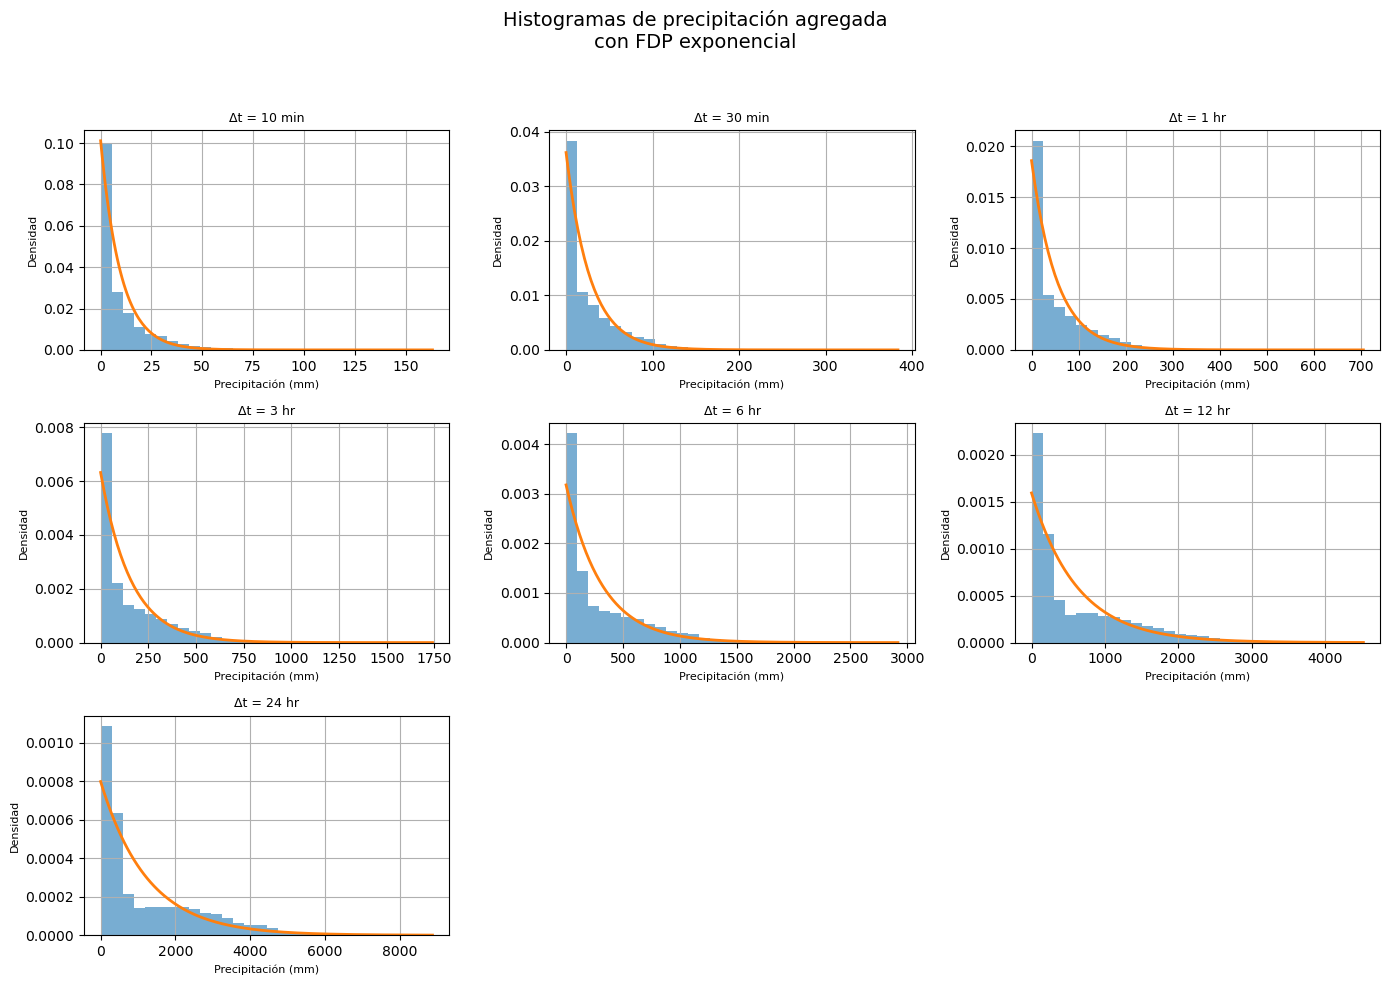

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, (label, series) in enumerate(aggregated.items()):
    hist_exp_subplot(
        axes[i],
        series.values,
        f"Δt = {label}",
        "Precipitación (mm)"
    )

# Eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histogramas de precipitación agregada\ncon FDP exponencial", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

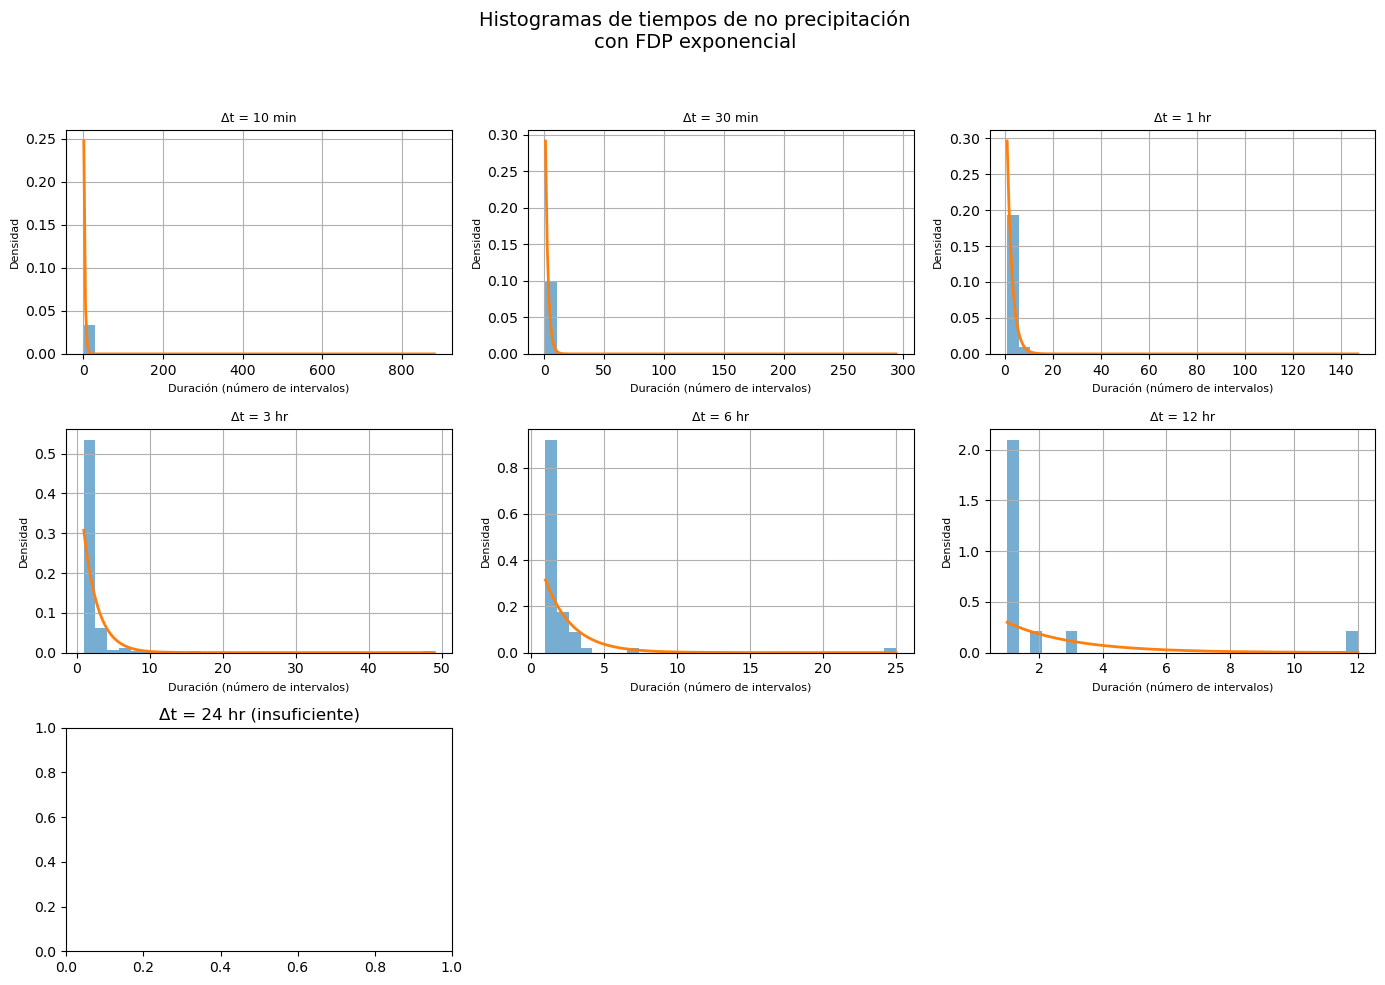

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, (label, series) in enumerate(aggregated.items()):
    dry = series == 0
    dry_runs = run_lengths(dry)

    hist_exp_subplot(
        axes[i],
        dry_runs,
        f"Δt = {label}",
        "Duración (número de intervalos)"
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histogramas de tiempos de no precipitación\ncon FDP exponencial", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

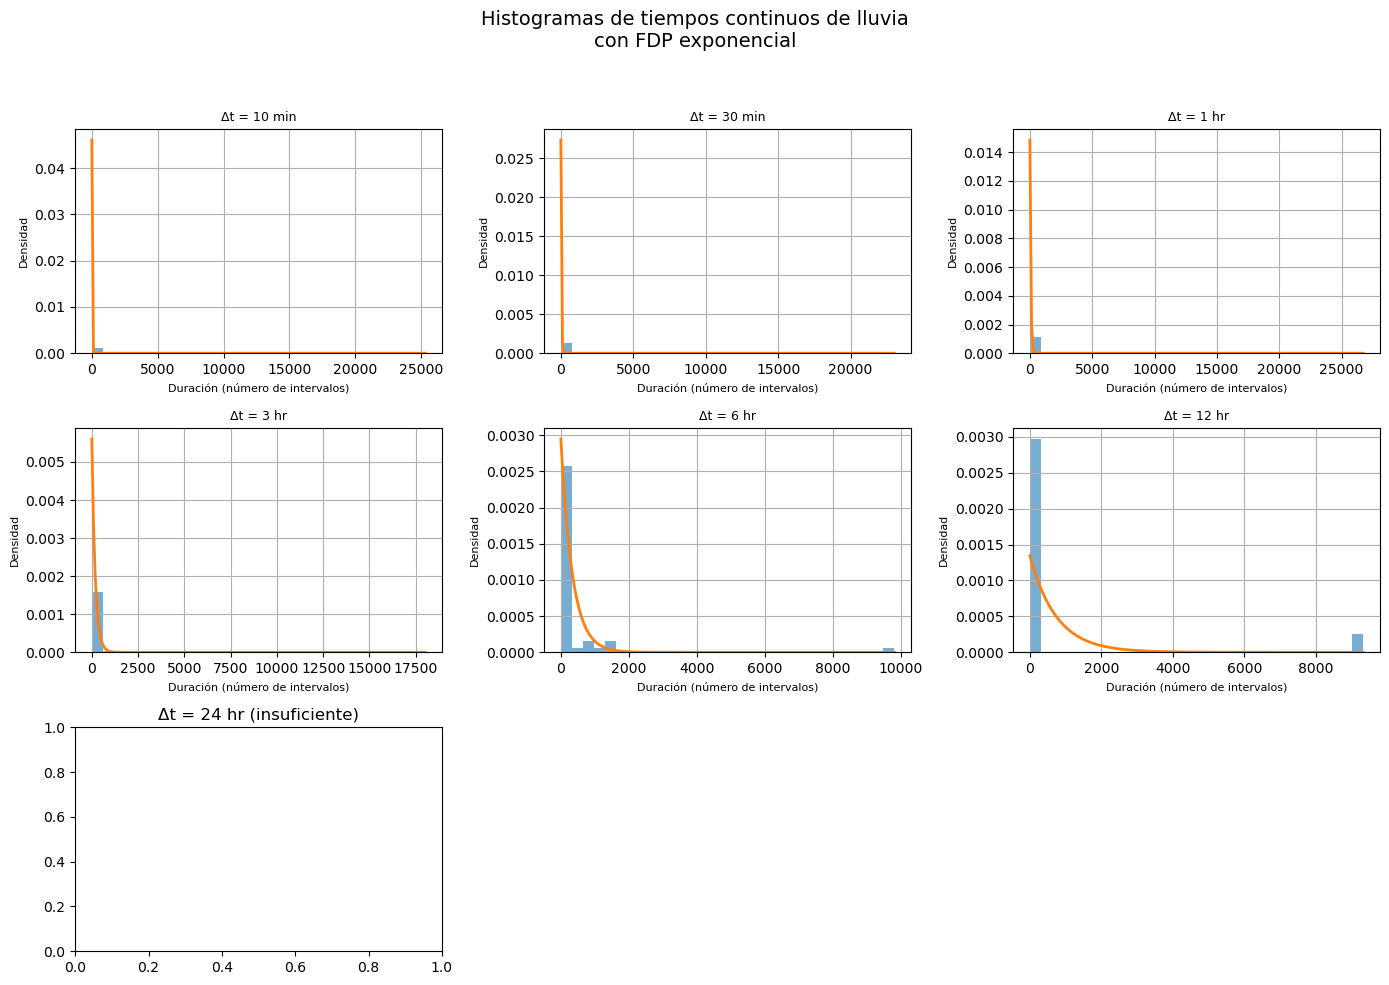

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, (label, series) in enumerate(aggregated.items()):
    wet = series > 0
    wet_runs = run_lengths(wet)

    hist_exp_subplot(
        axes[i],
        wet_runs,
        f"Δt = {label}",
        "Duración (número de intervalos)"
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histogramas de tiempos continuos de lluvia\ncon FDP exponencial", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# PUNTO 3

In [34]:
# ---- Leer datos ----
df_p = pd.read_csv('35107030_P.csv', parse_dates=['Fecha'])
df_c = pd.read_csv('35107030_C.csv', parse_dates=['Fecha'])

In [42]:
# ---- Función para graficar histogramas con densidad manual ----
def plot_hist_fdps_manual(data, title):
    plt.figure(figsize=(10,6))
    # Histograma
    sns.histplot(data, bins=20, stat='density', color='lightblue', label='Histograma')

    x = np.linspace(data.min(), data.max(), 200)

    # ---- Normal ----
    mu = data.mean()
    sigma = data.std()
    normal_pdf = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
    plt.plot(x, normal_pdf, 'r-', label='Normal')

    # ---- Exponencial ----
    lam = 1 / data.mean()  # lambda = 1/mean
    expon_pdf = lam * np.exp(-lam * x)
    plt.plot(x, expon_pdf, 'g--', label='Exponencial')

    # ---- Gamma ----
    mean = data.mean()
    var = data.var()
    alpha = mean**2 / var
    beta = var / mean
    # evitar división por cero
    gamma_pdf = np.zeros_like(x)
    gamma_pdf[x>0] = (x[x>0]**(alpha-1) * np.exp(-x[x>0]/beta)) / (beta**alpha * math.gamma(alpha))
    plt.plot(x, gamma_pdf, 'b-.', label='Gamma')

    plt.title(title)
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

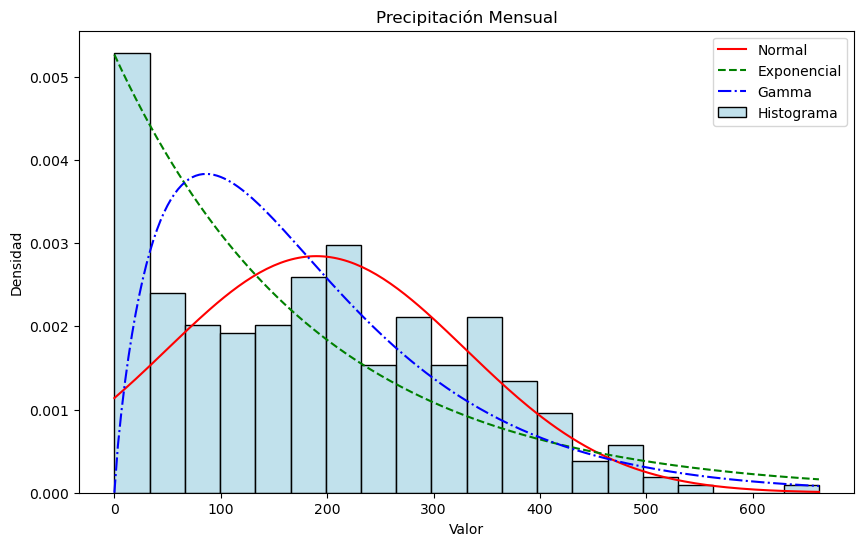

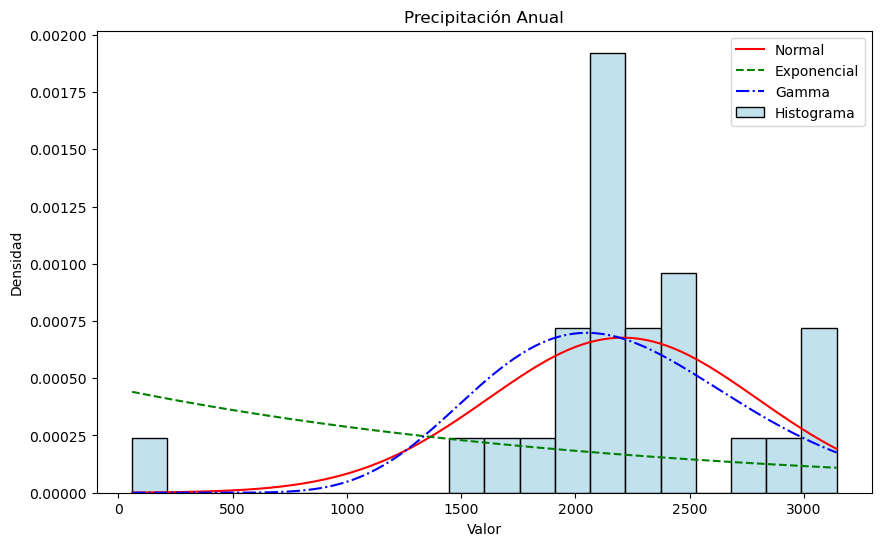

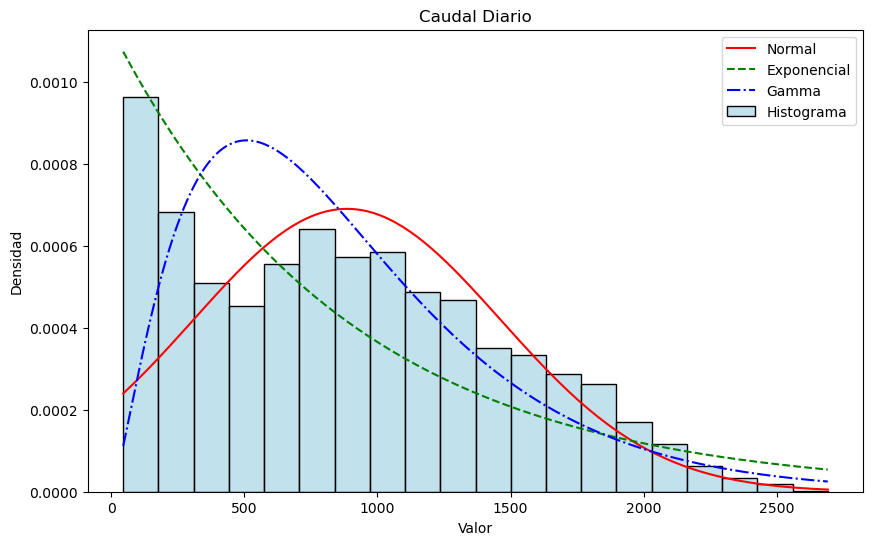

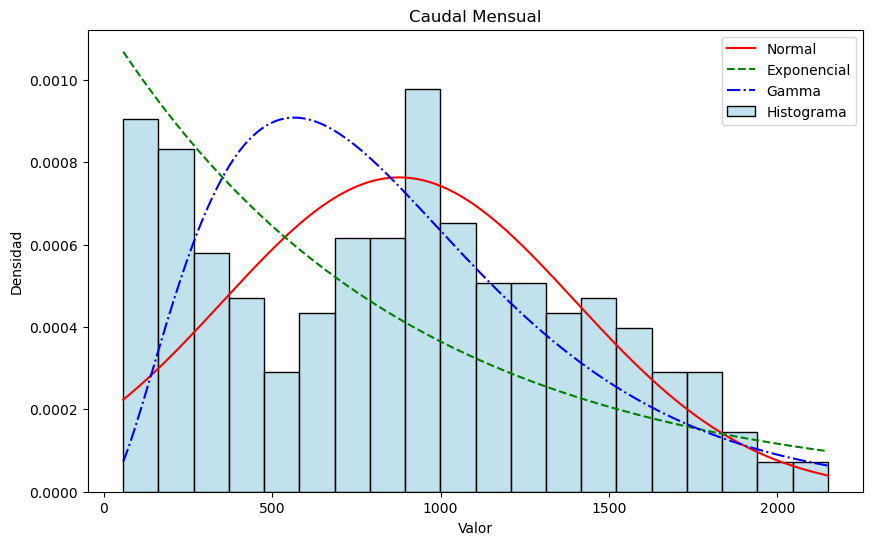

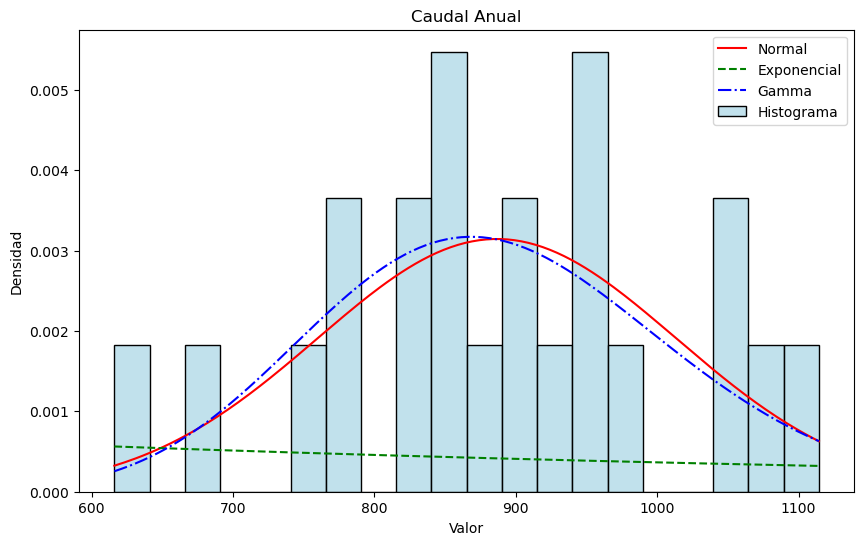

In [43]:
# ---- Precipitación ----
prec_mensual = df_p.resample('ME', on='Fecha')['Valor'].sum()
prec_anual = df_p.resample('YE', on='Fecha')['Valor'].sum()

plot_hist_fdps_manual(prec_mensual, 'Precipitación Mensual')
plot_hist_fdps_manual(prec_anual, 'Precipitación Anual')

# ---- Caudal ----
caudal_diario = df_c.set_index('Fecha')['Valor']
caudal_mensual = df_c.resample('ME', on='Fecha')['Valor'].mean()
caudal_anual = df_c.resample('YE', on='Fecha')['Valor'].mean()

plot_hist_fdps_manual(caudal_diario, 'Caudal Diario')
plot_hist_fdps_manual(caudal_mensual, 'Caudal Mensual')
plot_hist_fdps_manual(caudal_anual, 'Caudal Anual')

In [44]:
# ---- Función para calcular densidades sin scipy ----
def compute_fdps(data):
    x = np.linspace(data.min(), data.max(), 200)

    # Normal
    mu = data.mean()
    sigma = data.std()
    normal_pdf = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

    # Exponencial
    lam = 1 / data.mean()
    expon_pdf = lam * np.exp(-lam * x)

    # Gamma
    mean = data.mean()
    var = data.var()
    alpha = mean**2 / var
    beta = var / mean
    gamma_pdf = np.zeros_like(x)
    gamma_pdf[x>0] = (x[x>0]**(alpha-1) * np.exp(-x[x>0]/beta)) / (beta**alpha * math.gamma(alpha))

    return x, normal_pdf, expon_pdf, gamma_pdf

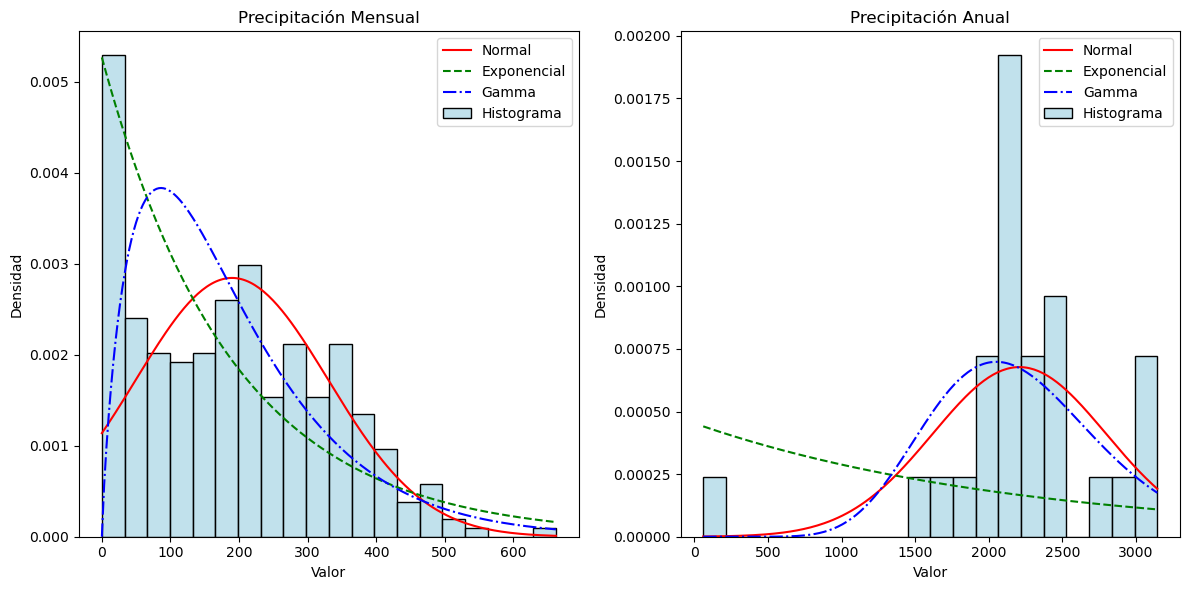

In [47]:
# ---- Precipitación ----
prec_mensual = df_p.resample('ME', on='Fecha')['Valor'].sum()
prec_anual = df_p.resample('YE', on='Fecha')['Valor'].sum()

prec_data = [prec_mensual, prec_anual]
prec_titles = ['Precipitación Mensual', 'Precipitación Anual']

plt.figure(figsize=(12,6))
for i, data in enumerate(prec_data):
    plt.subplot(1,2,i+1)
    sns.histplot(data, bins=20, stat='density', color='lightblue', label='Histograma')

    x, normal_pdf, expon_pdf, gamma_pdf = compute_fdps(data)
    plt.plot(x, normal_pdf, 'r-', label='Normal')
    plt.plot(x, expon_pdf, 'g--', label='Exponencial')
    plt.plot(x, gamma_pdf, 'b-.', label='Gamma')

    plt.title(prec_titles[i])
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.legend()

plt.tight_layout()
plt.show()

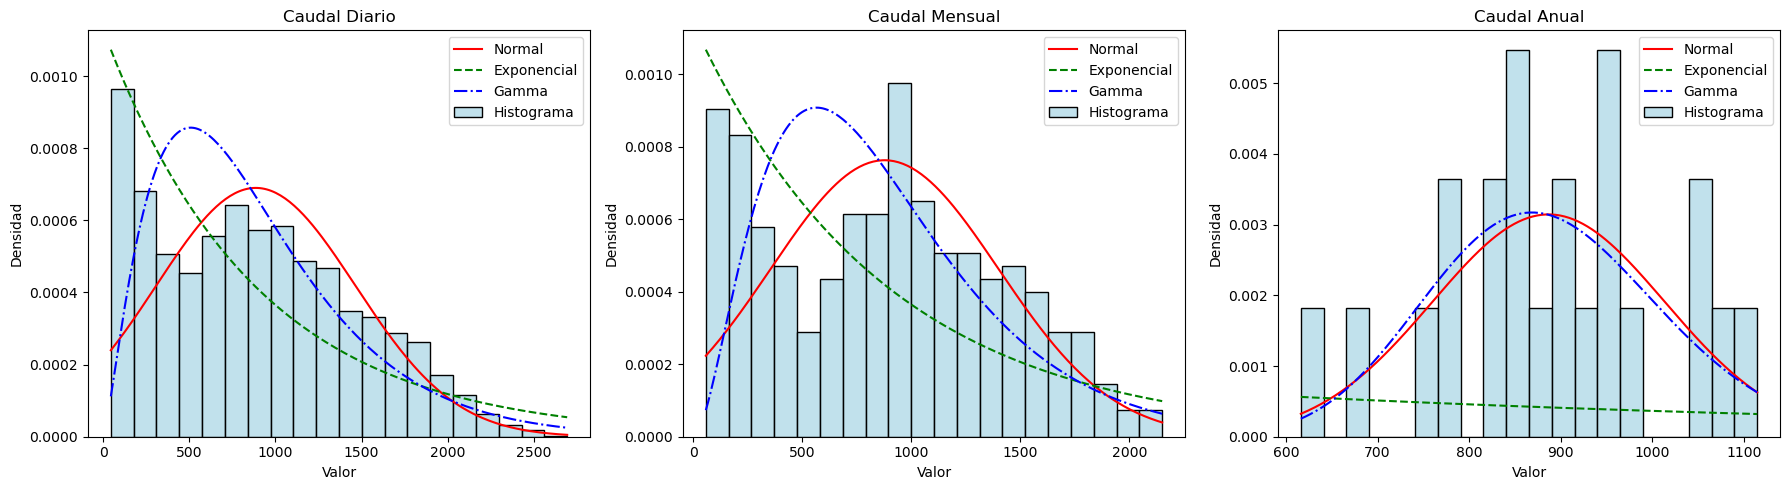

In [49]:
# ---- Caudal ----
caudal_diario = df_c.set_index('Fecha')['Valor']
caudal_mensual = df_c.resample('ME', on='Fecha')['Valor'].mean()
caudal_anual = df_c.resample('YE', on='Fecha')['Valor'].mean()

caudal_data = [caudal_diario, caudal_mensual, caudal_anual]
caudal_titles = ['Caudal Diario', 'Caudal Mensual', 'Caudal Anual']

plt.figure(figsize=(18,5))
for i, data in enumerate(caudal_data):
    plt.subplot(1,3,i+1)
    sns.histplot(data, bins=20, stat='density', color='lightblue', label='Histograma')

    x, normal_pdf, expon_pdf, gamma_pdf = compute_fdps(data)
    plt.plot(x, normal_pdf, 'r-', label='Normal')
    plt.plot(x, expon_pdf, 'g--', label='Exponencial')
    plt.plot(x, gamma_pdf, 'b-.', label='Gamma')

    plt.title(caudal_titles[i])
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.legend()

plt.tight_layout()
plt.show()

# PUNTO 4

In [50]:
# ---- Función para estimar parámetros de Gumbel por MLE ----
def gumbel_mle_params(data):
    """
    Estimación aproximada de parámetros de Gumbel (mu, beta) por MLE
    """
    # Método de momentos aproximado: 
    # beta = std * sqrt(6)/pi, mu = mean - 0.5772*beta
    mean = data.mean()
    std = data.std()
    beta = std * np.sqrt(6)/np.pi
    mu = mean - 0.5772*beta
    return mu, beta

In [51]:
# ---- Función para graficar histograma y Gumbel ----
def plot_hist_gumbel(data, title):
    plt.figure(figsize=(8,5))
    sns.histplot(data, bins=15, stat='density', color='lightblue', label='Histograma')

    # Estimar parámetros Gumbel
    mu, beta = gumbel_mle_params(data)

    # Función de densidad de Gumbel
    x = np.linspace(data.min(), data.max(), 200)
    gumbel_pdf = (1/beta) * np.exp(-(x - mu)/beta) * np.exp(-np.exp(-(x - mu)/beta))
    plt.plot(x, gumbel_pdf, 'r-', label='Gumbel')

    plt.title(title)
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

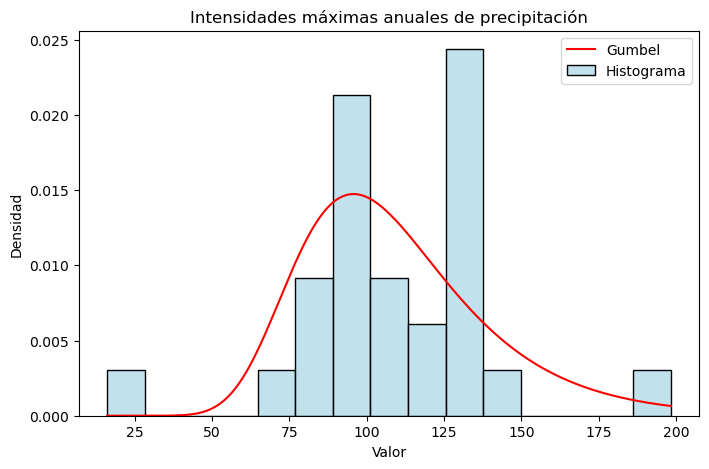

In [53]:
# ---- 1. Intensidades máximas anuales de precipitación ----
prec_max_anual = df_p.resample('YE', on='Fecha')['Valor'].max()
plot_hist_gumbel(prec_max_anual, 'Intensidades máximas anuales de precipitación')

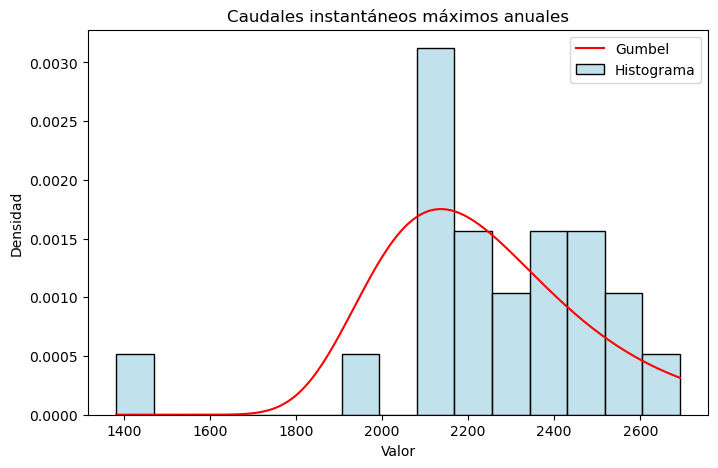

In [54]:
# ---- 2. Caudales instantáneos máximos anuales ----
# Asumimos que ya tienes la serie de máximos anuales en df_c['Valor']
caudal_max_instantaneo = df_c.resample('YE', on='Fecha')['Valor'].max()
plot_hist_gumbel(caudal_max_instantaneo, 'Caudales instantáneos máximos anuales')

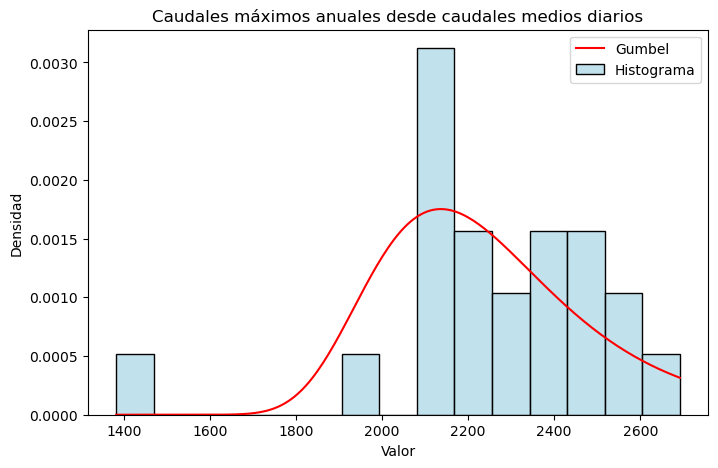

In [56]:
# ---- 3. Caudales máximos anuales desde caudales medios diarios ----
caudal_medio_diario = df_c.resample('D', on='Fecha')['Valor'].mean()
caudal_max_anual_desde_medio = caudal_medio_diario.resample('YE').max()
plot_hist_gumbel(caudal_max_anual_desde_medio, 'Caudales máximos anuales desde caudales medios diarios')

# PUNTO 5

In [2]:
header = {}
with open("mdt_srtm.txt") as f:
    for _ in range(6):
        key, value = f.readline().split()
        header[key.lower()] = float(value) if "." in value else int(value)

In [3]:
ncols = header["ncols"]
nrows = header["nrows"]
cellsize = header["cellsize"]
nodata = header["nodata_value"]

In [4]:
elev = np.loadtxt("mdt_srtm.txt", skiprows=6)

In [5]:
elev = elev.flatten()
elev = elev[elev != nodata]

In [6]:
area_pixel_km2 = (30 * 30) / 1e6  # 0.0009 km²

In [7]:
bins = np.arange(elev.min(), elev.max() + 100, 100)

In [8]:
counts, edges = np.histogram(elev, bins=bins)

In [9]:
area_km2 = counts * area_pixel_km2
elev_mid = 0.5 * (edges[:-1] + edges[1:])

In [10]:
area_acum = area_km2[::-1].cumsum()[::-1]

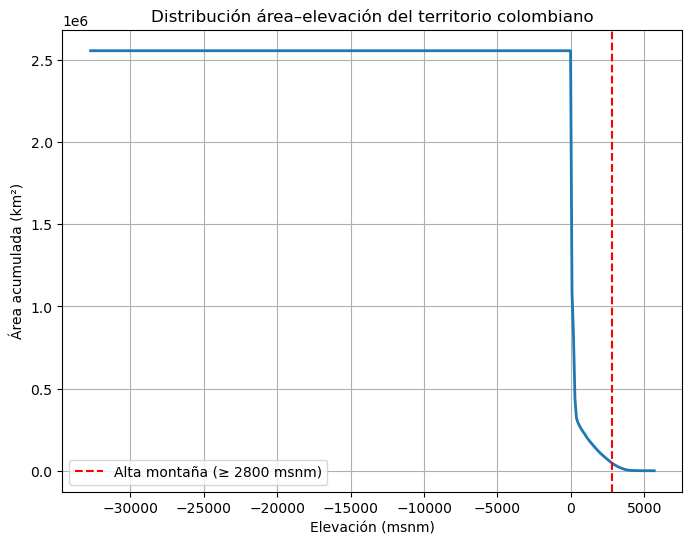

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(elev_mid, area_acum, linewidth=2)

plt.axvline(2800, linestyle="--", color="red",
            label="Alta montaña (≥ 2800 msnm)")

plt.xlabel("Elevación (msnm)")
plt.ylabel("Área acumulada (km²)")
plt.title("Distribución área–elevación del territorio colombiano")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
mask_alta = elev_mid >= 2800
area_alta = area_km2[mask_alta].sum()
area_total = area_km2.sum()

porcentaje = 100 * area_alta / area_total

area_alta, porcentaje

(np.float64(41558.8896), np.float64(1.6251501856037893))

In [13]:
print(header["ncols"])
print(header["nrows"])
print(header["cellsize"])
print(header["nodata_value"])

45816
62017
30
-9999


In [14]:
elev_2d = elev.reshape((45816, 62017))

In [18]:
da = xr.DataArray(
    elev_2d,
    dims=("y", "x"),
    name="elevation",
    attrs={
        "units": "m",
        "_FillValue": -9999
    }
)

In [21]:
da = da.rio.set_spatial_dims(x_dim="x", y_dim="y")
da = da.rio.write_crs("EPSG:4326", inplace=True)

In [22]:
da = da.where(da != -9999)

In [23]:
da = da.chunk({"y": 2048, "x": 2048})

da.to_netcdf(
    "mdt_srtm_colombia.nc",
    engine="netcdf4"
)